In [20]:
from pandas.io.parsers.readers import read_csv
import openai
import json
import pandas as pd
from google.colab import userdata
from tqdm.asyncio import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import asyncio
from openai import AsyncOpenAI
from google.colab import drive

drive.mount('/content/drive/')
folder_path = "drive/MyDrive/CS175/"

client = openai.OpenAI(api_key=userdata.get('OPENAI_KEY'))
async_client = AsyncOpenAI(api_key=userdata.get('OPENAI_KEY'))

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Evaluate Based on Generated Text's Sentiment

In [17]:
async def evaluate_texts(texts, model="gpt-5-nano"):
    RESPONSE_SCHEMA = {
        "type": "json_schema",
        "json_schema": {
            "name": "evaluation_result_schema",
            "strict": True,
            "schema": {
                "type": "object",
                "properties": {
                    "evaluations": {
                        "type": "array",
                        "items": {
                            "type": "object",
                            "properties": {
                                "Sentiment": {"type": "string", "enum": ["Positive", "Negative"]},
                                "Coherence": {"type": "integer", "description": "Score from 1 to 10"}
                            },
                            "required": ["Sentiment", "Coherence"],
                            "additionalProperties": False
                        }
                    }
                },
                "required": ["evaluations"],
                "additionalProperties": False
            }
        }
    }

    system_prompt = """
    You are a linguistic expert. Evaluate the provided sentences based on coherence and sentiment.
    Return a list of 8 evaluations corresponding to the input order.
    Coherence scale: 1 (gibberish/repetitive) to 10 (perfect flow).

    ### COHERENCE FEW-SHOT EXAMPLES ###
    - Text: "The movie was a masterpiece of storytelling, with incredible acting and a gripping plot."
      Eval: {"Sentiment": "Positive", "Coherence": 10} # reason: Natural, logical flow, and grammatically perfect.

    - Text: "The movie was good movie. I liked the movie and movie was fun to see the movie."
      Eval: {"Sentiment": "Positive", "Coherence": 5} # reason: Grammatically okay but highly repetitive and lacks vocabulary variety.

    - Text: "The movie was apple banana <div> error 404 repetitive repeat repeat."
      Eval: {"Sentiment": "Negative", "Coherence": 1} # reason: Gibberish, contains HTML noise and meaningless repetition.
    """

    user_content = "Please evaluate the following 8 sentences in order:\n"
    for i, t in enumerate(texts):
        user_content += f"{i+1}. {t}\n"

    response = await async_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content}
        ],
        response_format=RESPONSE_SCHEMA
    )

    return json.loads(response.choices[0].message.content).get("evaluations", [])

In [ ]:
target_columns = [
    'baseline', 'prompted',
    'steered_pos_rank1_5210', 'steered_pos_rank2_2219', 'steered_pos_rank3_3770',
    'steered_neg_rank1_176', 'steered_neg_rank2_4606', 'steered_neg_rank3_4773'
]

result_columns = []
for col in target_columns:
    result_columns.extend([f"{col}_Sentiment", f"{col}_Coherence", f"{col}_Normalized_Coherence"])

input_file = f'{folder_path}imdb_final_sweep.csv'
output_file = f'{folder_path}imdb_final_sweep_evaluated_results.csv'

try:
    df = pd.read_csv(output_file)
    print(f"Reading existing progress: {output_file}")
except:
    df = pd.read_csv(input_file)
    print(f"Reading base data: {input_file}")

for res_col in result_columns:
    if res_col not in df.columns:
        if "Sentiment" in res_col:
            df[res_col] = ""
            df[res_col] = df[res_col].astype(object)
        else:
            df[res_col] = np.nan

semaphore = asyncio.Semaphore(10)

async def process_row_with_semaphore(index, row_data, pbar, save_counter_list):
    async with semaphore:
        texts_to_eval = [row_data[col] for col in target_columns]
        try:
            eval_results = await evaluate_texts(texts_to_eval)
            if eval_results:
                for i, col_name in enumerate(target_columns):
                    df.at[index, f"{col_name}_Sentiment"] = eval_results[i].get('Sentiment')
                    df.at[index, f"{col_name}_Coherence"] = eval_results[i].get('Coherence')

            pbar.update(1)

            save_counter_list[0] += 1
            if save_counter_list[0] >= 20:
                df.to_csv(output_file, index=False)
                save_counter_list[0] = 0

        except Exception as e:
            print(f"Error processing index {index}: {e}")
            pbar.update(1)

async def main_continuous_processor():
    last_col_check = f"{target_columns[-1]}_Sentiment"
    pending_indices = df[df[last_col_check].isna() | (df[last_col_check] == "")].index.tolist()

    if not pending_indices:
        print("No pending rows to process.")
        return

    print(f"Starting continuous async processing for {len(pending_indices)} rows...")
    save_counter = [0]

    with tqdm(total=len(pending_indices)) as pbar:
        tasks = [
            process_row_with_semaphore(idx, df.loc[idx], pbar, save_counter)
            for idx in pending_indices
        ]
        await asyncio.gather(*tasks)

    df.to_csv(output_file, index=False)
    print(f"Processing complete. Final results saved to {output_file}")

await main_continuous_processor()

Normalizing with Min: 1.0, Max: 10.0


/tmp/ipykernel_397/3011992512.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean_Coherence', y='Condition', data=coherence_plot_data, palette='magma')


=== Analysis Summary ===
Average Positive Steering Success: 57.41%
Average Negative Steering Success (Positive Label %): 57.51%


<Figure size 1200x600 with 0 Axes>

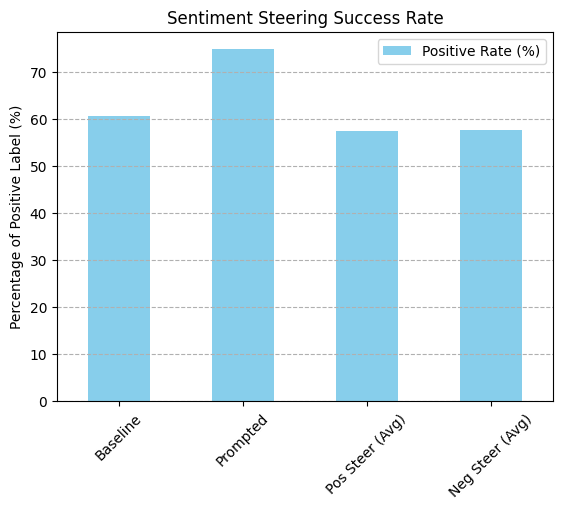

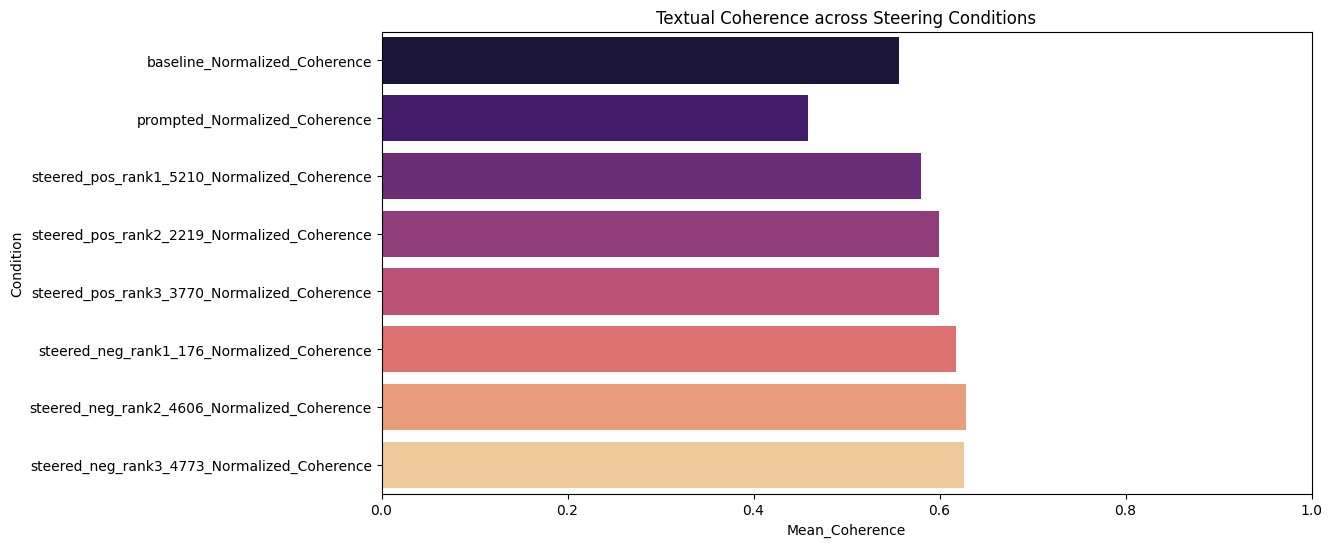

In [5]:
df = pd.read_csv(output_file)

coherence_cols = [f"{col}_Coherence" for col in target_columns]
all_coherence_values = df[coherence_cols].values.flatten()
min_val = np.nanmin(all_coherence_values)
max_val = np.nanmax(all_coherence_values)

print(f"Normalizing with Min: {min_val}, Max: {max_val}")

df.to_csv(output_file, index=False)

if max_val - min_val > 0:
    for col in target_columns:
        df[f"{col}_Normalized_Coherence"] = round(
            (df[f"{col}_Coherence"] - min_val) / (max_val - min_val), 2
        )

pos_steer_cols = ['steered_pos_rank1_5210_Sentiment', 'steered_pos_rank2_2219_Sentiment', 'steered_pos_rank3_3770_Sentiment']
neg_steer_cols = ['steered_neg_rank1_176_Sentiment', 'steered_neg_rank2_4606_Sentiment', 'steered_neg_rank3_4773_Sentiment']
coherence_cols = [col for col in df.columns if 'Normalized_Coherence' in col]

def calc_pos_rate(df, columns):
    rates = {}
    for col in columns:
        rates[col] = (df[col] == 'Positive').mean() * 100
    return pd.Series(rates)

coherence_means = df[coherence_cols].mean()

plt.figure(figsize=(12, 6))
sentiment_results = pd.DataFrame({
    'Baseline': (df['baseline_Sentiment'] == 'Positive').mean() * 100,
    'Prompted': (df['prompted_Sentiment'] == 'Positive').mean() * 100,
    'Pos Steer (Avg)': calc_pos_rate(df, pos_steer_cols).mean(),
    'Neg Steer (Avg)': calc_pos_rate(df, neg_steer_cols).mean()
}, index=['Positive Rate (%)']).T

sentiment_results.plot(kind='bar', color=['skyblue', 'orange', 'green', 'red'])
plt.title('Sentiment Steering Success Rate')
plt.ylabel('Percentage of Positive Label (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.savefig(f'{folder_path}sentiment_success.png')

plt.figure(figsize=(12, 6))
coherence_plot_data = coherence_means.reset_index()
coherence_plot_data.columns = ['Condition', 'Mean_Coherence']
sns.barplot(x='Mean_Coherence', y='Condition', data=coherence_plot_data, palette='magma')
plt.title('Textual Coherence across Steering Conditions')
plt.xlim(0, 1)
plt.savefig(f'{folder_path}coherence_analysis.png')

print("=== Analysis Summary ===")
print(f"Average Positive Steering Success: {calc_pos_rate(df, pos_steer_cols).mean():.2f}%")
print(f"Average Negative Steering Success (Positive Label %): {calc_pos_rate(df, neg_steer_cols).mean():.2f}%")

# Relative Sentiment

In [18]:
async def evaluate_texts(texts, model="gpt-5-nano"):
    RESPONSE_SCHEMA = {
    "type": "json_schema",
    "json_schema": {
        "name": "evaluation_result_schema",
        "strict": True,
        "schema": {
            "type": "object",
            "properties": {
                "evaluations": {
                    "type": "array",
                    "description": "A list of 8 evaluations. The first is the baseline; the subsequent 7 are comparisons.",
                    "items": {
                        "type": "object",
                        "properties": {
                            "Sentiment": {
                                "type": "integer",
                                "description": "For ID 1: 1=Pos, 0=Neu, -1=Neg. For IDs 2-8: 1=More Pos, -1=More Neg."
                            },
                            "Coherence": {
                                "type": "integer",
                                "description": "Score from 1 (gibberish) to 10 (perfect flow)."
                            }
                        },
                        "required": ["Sentiment", "Coherence"],
                        "additionalProperties": False
                    },
                    "minItems": 8,
                    "maxItems": 8
                }
            },
            "required": ["evaluations"],
            "additionalProperties": False
        }
    }
}

    system_prompt = """
    Role: You are a senior linguistic expert specializing in semantic analysis and text coherence.

    Task: You will be provided with a list of 8 sentences. Your goal is to evaluate each sentence for Coherence and perform a Comparative Sentiment Analysis using a specific numeric scale.

    Evaluation Logic:

    Baseline (Sentence 1): Identify its absolute sentiment.

    1 = Positive

    0 = Neutral

    -1 = Negative

    Comparison (Sentences 2–8): Compare their sentiment relative to the Baseline.

    1 = More Positive than Baseline

    -1 = More Negative than Baseline

    Coherence Scale (1-10):

    1-3: Gibberish, HTML noise, or extreme repetition.

    4-7: Grammatically functional but lacks flow, variety, or clarity.

    8-10: Natural, sophisticated, and logically flawless.
    """

    user_content = "Please evaluate the following 8 sentences in order:\n"
    for i, t in enumerate(texts):
        user_content += f"{i+1}. {t}\n"

    response = await async_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content}
        ],
        response_format=RESPONSE_SCHEMA
    )

    return json.loads(response.choices[0].message.content).get("evaluations", [])

In [25]:
target_columns = [
    'baseline', 'prompted',
    'steered_pos_rank1_5210', 'steered_pos_rank2_2219', 'steered_pos_rank3_3770',
    'steered_neg_rank1_176', 'steered_neg_rank2_4606', 'steered_neg_rank3_4773'
]

result_columns = []
for col in target_columns:
    result_columns.extend([f"{col}_Sentiment", f"{col}_Coherence"])

input_file = f'{folder_path}imdb_final_sweep.csv'
output_file = f'{folder_path}imdb_final_sweep_evaluated_results[relative].csv'

try:
    df = pd.read_csv(output_file)
    print(f"Reading existing progress: {output_file}")
except:
    df = pd.read_csv(input_file)
    print(f"Reading base data: {input_file}")

for res_col in result_columns:
    if res_col not in df.columns:
        if "Sentiment" in res_col:
            df[res_col] = ""
            df[res_col] = df[res_col].astype(object)
        else:
            df[res_col] = np.nan

semaphore = asyncio.Semaphore(20)

async def process_row_with_semaphore(index, row_data, pbar, save_counter_list):
    async with semaphore:
        texts_to_eval = [row_data[col] for col in target_columns]

        retry_delay = 5
        while True:
            try:
                eval_results = await evaluate_texts(texts_to_eval)
                if eval_results:
                    for i, col_name in enumerate(target_columns):
                        df.at[index, f"{col_name}_Sentiment"] = eval_results[i].get('Sentiment')
                        df.at[index, f"{col_name}_Coherence"] = eval_results[i].get('Coherence')

                pbar.update(1)

                save_counter_list[0] += 1
                if save_counter_list[0] >= 2:
                    df.to_csv(output_file, index=False)
                    save_counter_list[0] = 0
                break;

            except Exception as e:
                error_msg = str(e)
                if "429" in error_msg or "rate_limit_exceeded" in error_msg:
                    wait_time = retry_delay + random.uniform(0, 1)
                    # print(f"Index {index}: Rate limit reached. Retrying in {wait_time:.2f}s...")
                    await asyncio.sleep(wait_time)
                else:
                    print(f"Error processing index {index}: {e}")
                    pbar.update(1)
                    break

async def main_continuous_processor():
    last_col_check = f"{target_columns[-1]}_Sentiment"
    pending_indices = df[df[last_col_check].isna() | (df[last_col_check] == "")].index.tolist()
    # pending_indices = pending_indices[:200]
    if not pending_indices:
        print("No pending rows to process.")
        return

    print(f"Total rows: {len(df)}")
    print(f"Completed rows: {len(df) - len(pending_indices)}")
    print(f"Starting continuous async processing for {len(pending_indices)} rows...")
    save_counter = [0]

    with tqdm(total=len(pending_indices)) as pbar:
        tasks = [
            process_row_with_semaphore(idx, df.loc[idx], pbar, save_counter)
            for idx in pending_indices
        ]
        await asyncio.gather(*tasks)

    df.to_csv(output_file, index=False)
    print(f"Processing complete. Final results saved to {output_file}")

await main_continuous_processor()

Reading existing progress: drive/MyDrive/CS175/imdb_final_sweep_evaluated_results[relative].csv
No pending rows to process.


/tmp/ipykernel_1023/3231345885.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Condition', y='Mean Relative Sentiment', data=plot_df, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_1023/3231345885.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(sentiment_cols, rotation=45, ha='right')
/tmp/ipykernel_1023/3231345885.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Condition', y='Mean Normalized Coherence', data=plot_df, ax=axes[1], palette='viridis')
/tmp/ipykernel_1023/3231345885.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks

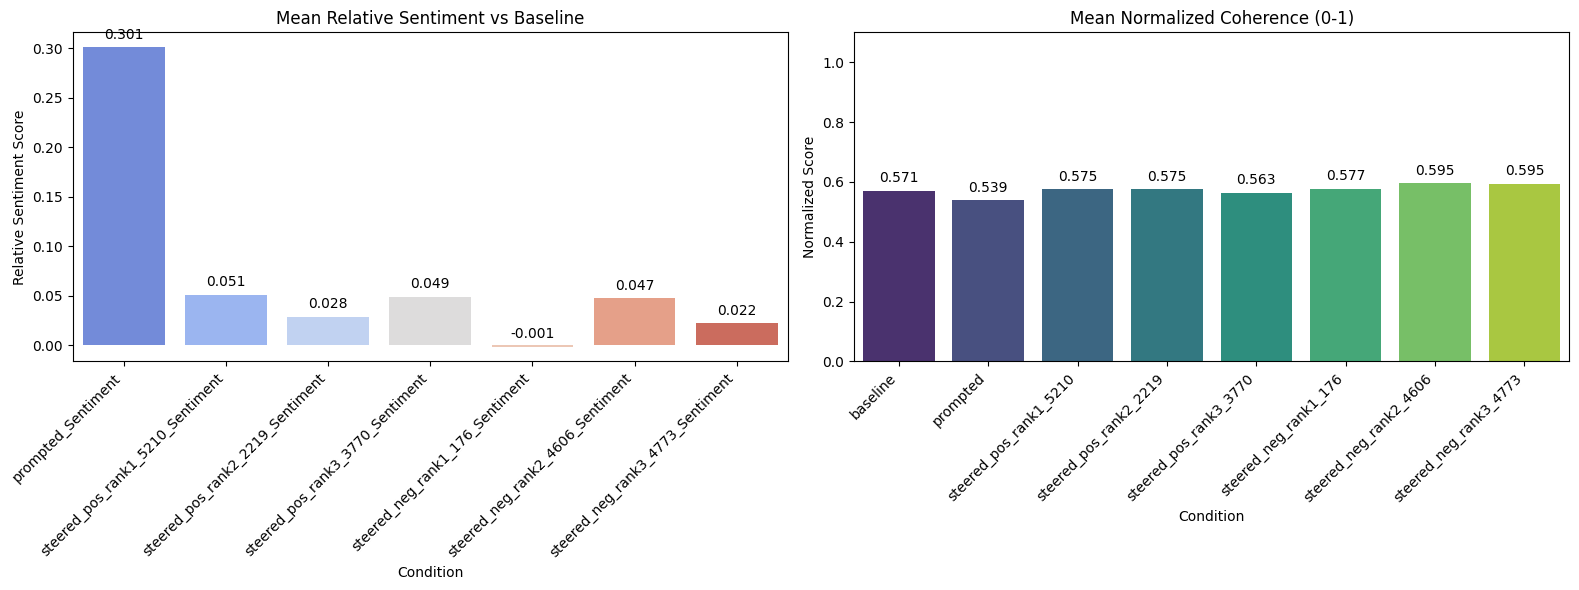

In [26]:
df_rel = pd.read_csv(output_file)

target_cols = [
    'baseline', 'prompted',
    'steered_pos_rank1_5210', 'steered_pos_rank2_2219', 'steered_pos_rank3_3770',
    'steered_neg_rank1_176', 'steered_neg_rank2_4606', 'steered_neg_rank3_4773'
]
sentiment_cols = [f'{col}_Sentiment' for col in target_cols if col != "baseline"]
coherence_cols = [f'{col}_Coherence' for col in target_cols]

sent_means = df_rel[sentiment_cols].mean()

for col in coherence_cols:
    df_rel[f'{col}_norm'] = (df_rel[col] - 1) / 9.0

norm_coherence_cols = [f'{col}_norm' for col in coherence_cols]
coh_means = df_rel[norm_coherence_cols].mean()

plot_df = pd.DataFrame({
    'Condition': sentiment_cols,
    'Mean Relative Sentiment': sent_means.values
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Condition', y='Mean Relative Sentiment', data=plot_df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Mean Relative Sentiment vs Baseline')
axes[0].set_xticklabels(sentiment_cols, rotation=45, ha='right')
axes[0].set_ylabel('Relative Sentiment Score')

for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plot_df = pd.DataFrame({
    'Condition': coherence_cols,
    'Mean Normalized Coherence': coh_means.values
})

sns.barplot(x='Condition', y='Mean Normalized Coherence', data=plot_df, ax=axes[1], palette='viridis')
axes[1].set_title('Mean Normalized Coherence (0-1)')
axes[1].set_xticklabels(target_cols, rotation=45, ha='right')
axes[1].set_ylabel('Normalized Score')
axes[1].set_ylim(0, 1.1)

for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')
plt.tight_layout()
plt.show()